In [1]:
from dotenv import load_dotenv
from IPython.display import display, Markdown

In [2]:
load_dotenv()

True

#### Define State

In [3]:
from collections.abc import Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage

from typing import Annotated
from langgraph.graph import add_messages

In [4]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

#### Define Node

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AIMessage, HumanMessage, RemoveMessage
from langchain_core.output_parsers import StrOutputParser

In [6]:
chat = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite-preview",
    temperature = 0.6,
    max_output_tokens = 100,
    seed = 0
)

In [7]:
def ask_ques(state: State) -> State:
    print("\n", state, "\n")

    ai_msg = "Hi! How can I help you?"
    print("AI: ", ai_msg)
    
    hum_msg = input(ai_msg)
    print("Human: ", hum_msg)

    return State(messages = [AIMessage(ai_msg), HumanMessage(hum_msg)])    

In [8]:
def chatbot(state: State) -> State:
    print("\n", state, "\n")

    print("Entering Chatbot...")

    response = chat.invoke(state["messages"])
    display(Markdown(StrOutputParser().invoke(response)))

    return State(messages = [response])

In [9]:
def ask_more(state: State) -> State:
    print("\n", state, "\n")

    ai_msg = "Would you like to ask another question? (yes/no)"
    print("AI: ", ai_msg)
    
    hum_msg = input(ai_msg)
    print("Human: ", hum_msg)

    return State(messages = [AIMessage(ai_msg), HumanMessage(hum_msg)])

In [10]:
def trim_message_history(state: State) -> State:
    print("Trimming message history...")

    removed_messages = [RemoveMessage(id = i.id) for i in state["messages"][:-5]]

    return State(messages = removed_messages)

add_message reducer function can also remove messages when paired with RemoveMessage class

#### Define Routing Function

In [11]:
def routing_fn(state: State) -> str:
    if state["messages"][-1].content == "yes":
        return "yes"

    else:
        return "no"

#### Define Graph

In [12]:
from langgraph.graph import StateGraph

In [13]:
graph = StateGraph(State)

In [14]:
graph.add_node("Ask Question", ask_ques)
graph.add_node("ChatBot", chatbot)
graph.add_node("Ask More", ask_more)
graph.add_node("Trim Message History", trim_message_history)

graph.add_edge("__start__", "Ask Question")
graph.add_edge("Ask Question", "ChatBot")
graph.add_edge("ChatBot", "Ask More")
graph.add_edge("Trim Message History", "Ask Question")

graph.add_conditional_edges(
    source = "Ask More",
    path = routing_fn,
    path_map = {"yes": "Trim Message History", "no": "__end__"}
)

In [15]:
graph = graph.compile()

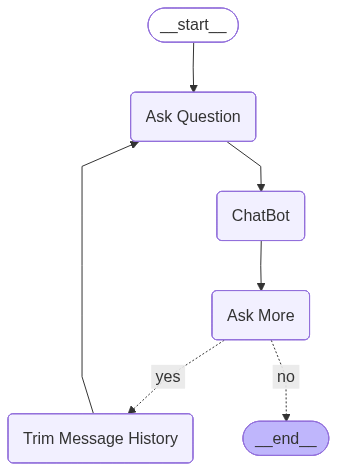

In [16]:
graph

#### Test the graph

In [17]:
graph.invoke(State(messages = []))


 {'messages': []} 

AI:  Hi! How can I help you?
Human:  Give me a famous but short poem. Write the poem only.

 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='05536302-e2c8-4bba-812f-9e14cdcc5163', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Give me a famous but short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='7845e08c-7277-4fb0-8a7a-8bd066b00555')]} 

Entering Chatbot...


I wandered lonely as a cloud
That floats on high o'er vales and hills,
When all at once I saw a crowd,
A host, of golden daffodils;
Beside the lake, beneath the trees,
Fluttering and dancing in the breeze.


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='05536302-e2c8-4bba-812f-9e14cdcc5163', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Give me a famous but short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='7845e08c-7277-4fb0-8a7a-8bd066b00555'), AIMessage(content=[{'type': 'text', 'text': "I wandered lonely as a cloud\nThat floats on high o'er vales and hills,\nWhen all at once I saw a crowd,\nA host, of golden daffodils;\nBeside the lake, beneath the trees,\nFluttering and dancing in the breeze.", 'extras': {'signature': 'EjQKMgERTTIPfrBIqsH7DPZaqzegQsCWCP7sEJgmJsU37+jQoNwE9CUBHR7xTwvx7BXwaxiD'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f55bc-4335-7f33-b18f-8619ba235cf7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2

The poet is William Wordsworth.


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='05536302-e2c8-4bba-812f-9e14cdcc5163', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Give me a famous but short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='7845e08c-7277-4fb0-8a7a-8bd066b00555'), AIMessage(content=[{'type': 'text', 'text': "I wandered lonely as a cloud\nThat floats on high o'er vales and hills,\nWhen all at once I saw a crowd,\nA host, of golden daffodils;\nBeside the lake, beneath the trees,\nFluttering and dancing in the breeze.", 'extras': {'signature': 'EjQKMgERTTIPfrBIqsH7DPZaqzegQsCWCP7sEJgmJsU37+jQoNwE9CUBHR7xTwvx7BXwaxiD'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f55bc-4335-7f33-b18f-8619ba235cf7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2

William Wordsworth was born on **April 7, 1770**, in **Cockermouth, Cumberland, England**.

Would you like to ask another question? (yes/no)


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='63b276e3-93b3-48f9-a7ee-6b2822c673fd', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Who is the poet of this poem?', additional_kwargs={}, response_metadata={}, id='3164c3ef-1e84-477f-9084-28e6f340fbc6'), AIMessage(content=[{'type': 'text', 'text': 'The poet is William Wordsworth.', 'extras': {'signature': 'EjQKMgERTTIPZFzvqCq9oOnBcvV3CRCGer6t1BLSToYPmfivePMTGLUbSCeQHcNXgk8jom9A'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f55bc-82cb-7e23-b594-e4ececa69ab1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 114, 'output_tokens': 6, 'total_tokens': 120, 'input_token_details': {'cache_read': 0}}), AIMessage(content='Would you like to ask another question? (yes/no)', additional_kwargs={}, response_metadata={}, 

Actually, I haven't shared a specific poem with you in our current conversation yet! We just discussed William Wordsworth's birth details.

Would you like me to share one of his poems with you, or were you thinking of a different poet?


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='cfe5df90-259e-4111-81fc-575b21eaffeb', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='When and where was the poet born?', additional_kwargs={}, response_metadata={}, id='edbf79a6-b6af-478e-a684-06c635b4f294'), AIMessage(content=[{'type': 'text', 'text': 'William Wordsworth was born on **April 7, 1770**, in **Cockermouth, Cumberland, England**.\n\nWould you like to ask another question? (yes/no)', 'extras': {'signature': 'EjQKMgERTTIPh+f/E5t/9Isaq3KSHqVicFv3BtMkmmdcoD4XHO+dXJyPDBhilTiZLrcHmKXf'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f55bc-e722-72d1-82cc-00a46bad065d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 40, 'total_tokens': 99, 'input_token_details': {'cache_read': 0}}), 

{'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='cfe5df90-259e-4111-81fc-575b21eaffeb', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='When and where was the poet born?', additional_kwargs={}, response_metadata={}, id='edbf79a6-b6af-478e-a684-06c635b4f294'),
  AIMessage(content=[{'type': 'text', 'text': 'William Wordsworth was born on **April 7, 1770**, in **Cockermouth, Cumberland, England**.\n\nWould you like to ask another question? (yes/no)', 'extras': {'signature': 'EjQKMgERTTIPh+f/E5t/9Isaq3KSHqVicFv3BtMkmmdcoD4XHO+dXJyPDBhilTiZLrcHmKXf'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f55bc-e722-72d1-82cc-00a46bad065d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 40, 'total_tokens': 99, 'input_token_details': {'cache_read': 0}})

Trimming works fine when the subject of the conversation is frequently mentioned

However, conversation deatails might get lost along the way